In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
df=pd.read_csv("09_portfolio_holdings.csv")

In [6]:
df.head(10)

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31
5,119551,NTPC,NTPC Ltd,Utilities,7.48,897.70,2913.66,2025-12-31
6,119551,DIVISLAB,Divi's Laboratories,Pharma,3.21,286.44,3964.01,2025-12-31
7,119551,BHARTIARTL,Bharti Airtel Ltd,Telecom,13.94,452.19,5013.45,2025-12-31
8,119551,HCLTECH,HCL Technologies Ltd,IT,18.22,177.35,6024.13,2025-12-31
9,119551,MARUTI,Maruti Suzuki India Ltd,Automobile,7.20,1982.33,5461.85,2025-12-31


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB


In [9]:
df.describe()

,amfi_code,weight_pct,market_value_cr,current_price_inr
count,322.000000,322.000000,322.000000,322.000000
mean,121210.434783,10.558975,1008.846646,4080.870528
std,14669.377920,6.060137,543.827535,2265.186353
min,100016.000000,0.990000,55.740000,246.780000
25%,118633.000000,6.015000,513.702500,2081.985000
50%,119552.000000,9.395000,1045.670000,4138.995000
75%,120842.750000,13.917500,1477.502500,5914.307500
max,149324.000000,38.180000,1999.500000,7942.960000


In [10]:
df.duplicated

<bound method DataFrame.duplicated of      amfi_code stock_symbol                 stock_name       sector  \
0       119551    POWERGRID     Power Grid Corporation    Utilities   
1       119551     HDFCBANK              HDFC Bank Ltd      Banking   
2       119551       GRASIM      Grasim Industries Ltd  Diversified   
3       119551      DRREDDY   Dr. Reddy's Laboratories       Pharma   
4       119551   ASIANPAINT           Asian Paints Ltd       Paints   
..         ...          ...                        ...          ...   
317     149324     DIVISLAB        Divi's Laboratories       Pharma   
318     149324   BHARTIARTL          Bharti Airtel Ltd      Telecom   
319     149324          TCS  Tata Consultancy Services           IT   
320     149324   INDUSINDBK          IndusInd Bank Ltd      Banking   
321     149324         NTPC                   NTPC Ltd    Utilities   

     weight_pct  market_value_cr  current_price_inr portfolio_date  
0         13.85           737.09        

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date       0
dtype: int64

In [14]:
df.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [15]:
df["sector"].value_counts()

sector
Banking           60
IT                40
Pharma            38
Automobile        33
Utilities         24
Infrastructure    22
FMCG              21
Telecom           15
Diversified       14
Energy            13
Cement            12
NBFC              11
Paints            10
Consumer Goods     9
Name: count, dtype: int64

In [16]:
df["portfolio_date"].unique()

array(['2025-12-31'], dtype=object)

In [17]:
df["portfolio_date"] = pd.to_datetime(df["portfolio_date"])

In [18]:
df["portfolio_date"].unique()

<DatetimeArray>
['2025-12-31 00:00:00']
Length: 1, dtype: datetime64[ns]

In [19]:
numeric_cols = ["weight_pct", "market_value_cr", "current_price_inr"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

weight_pct: 8 outliers
market_value_cr: 0 outliers
current_price_inr: 0 outliers


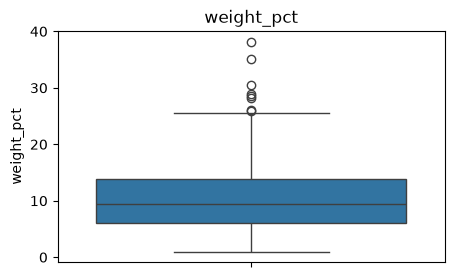

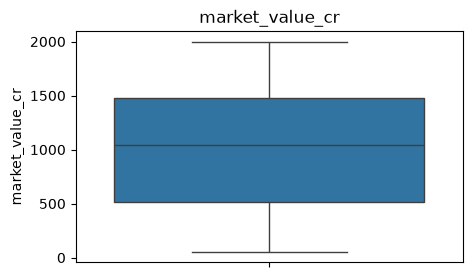

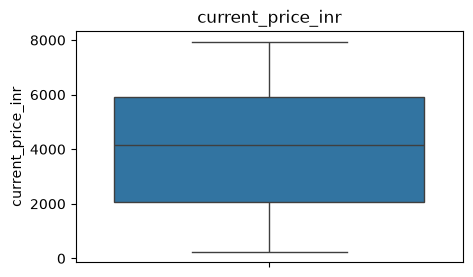

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["weight_pct", "market_value_cr", "current_price_inr"]

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

In [21]:
Q1 = df["weight_pct"].quantile(0.25)
Q3 = df["weight_pct"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["is_outlier_weight_pct"] = (
    (df["weight_pct"] < lower) |
    (df["weight_pct"] > upper)
)

In [22]:
df[df["is_outlier_weight_pct"]]

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,is_outlier_weight_pct
40,119599,GRASIM,Grasim Industries Ltd,Diversified,28.25,1461.32,1872.83,2025-12-31,True
44,100016,WIPRO,Wipro Ltd,IT,25.90,552.43,579.31,2025-12-31,True
64,100033,M&M,Mahindra & Mahindra Ltd,Automobile,26.07,511.03,3852.87,2025-12-31,True
118,118632,BHARTIARTL,Bharti Airtel Ltd,Telecom,30.44,1574.52,6271.17,2025-12-31,True
183,119092,INFY,Infosys Ltd,IT,38.18,1254.80,3939.80,2025-12-31,True
229,101207,SUNPHARMA,Sun Pharmaceutical Industries,Pharma,35.07,285.75,5455.74,2025-12-31,True
245,102885,NTPC,NTPC Ltd,Utilities,28.95,994.90,4140.59,2025-12-31,True
276,148568,SBIN,State Bank of India,Banking,28.61,498.31,2893.58,2025-12-31,True


In [23]:
df.to_csv("09_portfolio_holdings_clean.csv", index=False)